In [2]:
import matplotlib.pyplot as plt
import numpy as np

# from emerald.classical.coulomb_driven import C_forced_Phase_Space
from emerald.classical.dynamics import RegularizedDynamics, Trajectory, ClassicalSystem
from emerald.fields import SinusoidField
from emerald.integrators.regularized import RegularizedScipyIntegrator
from emerald.potentials import Coulomb


In [6]:
1/0.6

1.6666666666666667

In [3]:
integ = RegularizedScipyIntegrator(method="RK45", rtol=1e-9, atol=1e-12)
field = SinusoidField(amplitude=0.025, ang_frequency=1., phase=np.pi)

cou = Coulomb()

regdyn = RegularizedDynamics(cou, field)

r0 = 1.5

states0 = [[r0, p] for p in [cou.momentum(-0.4, r0), cou.momentum(-0.5 ,r0), cou.momentum(-0.6, r0)]]

syst = ClassicalSystem(regdyn, np.asarray(states0))

In [4]:
pmap = syst.poincare_map(integ, Nt=500)

particle 0: nfev=187712  steps=29919  status=1
particle 1: nfev=187886  steps=29760  status=1
particle 2: nfev=278456  steps=43384  status=1


(-3.0, 3.0)

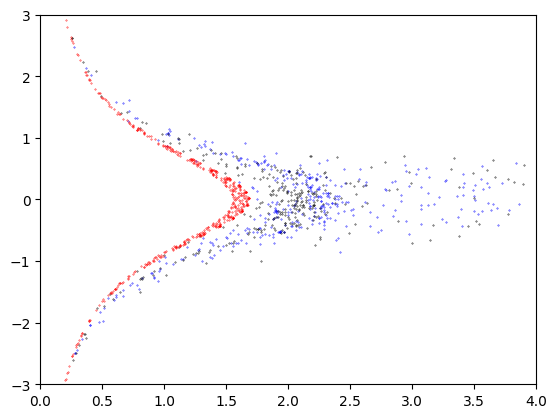

In [5]:
cols = ['blue', 'black', 'red']
for i in range(pmap.N_trajectories):
    particle_map = pmap.for_particle(i)
    plt.scatter(particle_map.position, particle_map.momentum, s=0.1, label=f"$E = {particle_map.energy[0]:.2f}$", c=cols[i])
plt.xlim(0, 4)
plt.ylim(-3, 3)

In [6]:
pmap.ionization_probability()

0.0

In [7]:
syst = ClassicalSystem.from_energy(regdyn, -0.5, 100)

/media/gabriel/AcerD/Documentos/cursos/IC/Morse-Coulomb/Dev/src/emerald/potentials/coulomb.py:20: RuntimeWarning: divide by zero encountered in divide
  return np.where( r > 0, -1 / r, np.infty)


In [8]:
syst.states0

array([[ 0.04081633, -6.92820323],
       [ 0.08163265, -4.84767986],
       [ 0.12244898, -3.91578004],
       [ 0.16326531, -3.35410197],
       [ 0.20408163, -2.96647939],
       [ 0.24489796, -2.67706307],
       [ 0.28571429, -2.44948974],
       [ 0.32653061, -2.26384628],
       [ 0.36734694, -2.10818511],
       [ 0.40816327, -1.97484177],
       [ 0.44897959, -1.85864075],
       [ 0.48979592, -1.75594229],
       [ 0.53061224, -1.66410059],
       [ 0.57142857, -1.58113883],
       [ 0.6122449 , -1.50554531],
       [ 0.65306122, -1.43614066],
       [ 0.69387755, -1.37198868],
       [ 0.73469388, -1.31233465],
       [ 0.7755102 , -1.25656172],
       [ 0.81632653, -1.20415946],
       [ 0.85714286, -1.15470054],
       [ 0.89795918, -1.10782342],
       [ 0.93877551, -1.06321907],
       [ 0.97959184, -1.02062073],
       [ 1.02040816, -0.9797959 ],
       [ 1.06122449, -0.94053994],
       [ 1.10204082, -0.90267093],
       [ 1.14285714, -0.8660254 ],
       [ 1.18367347,

In [9]:
traj2 = syst.propagate(integ, (0, 50), np.linspace(0, 50, 5000))

particle 0: nfev=3752  steps=599  status=1
particle 1: nfev=3740  steps=598  status=1
particle 2: nfev=3740  steps=598  status=1
particle 3: nfev=3746  steps=598  status=1
particle 4: nfev=3764  steps=598  status=1
particle 5: nfev=3764  steps=598  status=1
particle 6: nfev=3734  steps=597  status=1
particle 7: nfev=3746  steps=597  status=1
particle 8: nfev=3746  steps=597  status=1
particle 9: nfev=3770  steps=597  status=1
particle 10: nfev=3740  steps=596  status=1
particle 11: nfev=3740  steps=596  status=1
particle 12: nfev=3764  steps=596  status=1
particle 13: nfev=3764  steps=596  status=1
particle 14: nfev=3758  steps=596  status=1
particle 15: nfev=3776  steps=596  status=1
particle 16: nfev=3776  steps=596  status=1
particle 17: nfev=3782  steps=596  status=1
particle 18: nfev=3770  steps=596  status=1
particle 19: nfev=3776  steps=595  status=1
particle 20: nfev=3794  steps=596  status=1
particle 21: nfev=3794  steps=596  status=1
particle 22: nfev=3788  steps=595  status=

In [10]:
traj2.angle

array([[-3.91133249e-03, -1.11325126e-02, -2.05825158e-02, ...,
         2.33900221e+00,  2.57211371e+00,  0.00000000e+00],
       [ 6.07058197e-03, -1.12434168e-03, -1.05723920e-02, ...,
         2.34897930e+00,  2.58209691e+00, -3.13159516e+00],
       [ 1.60582662e-02,  8.86659535e-03, -5.71135210e-04, ...,
         2.35895735e+00,  2.59207752e+00, -3.12160779e+00],
       ...,
       [-5.19482862e-01, -5.33119676e-01, -5.50934725e-01, ...,
        -1.48542197e+00, -2.79100973e+00,  2.84746352e+00],
       [-5.10207662e-01, -5.23861010e-01, -5.41696809e-01, ...,
        -1.47786687e+00, -2.78289985e+00,  2.85814600e+00],
       [-5.01035722e-01, -5.14702509e-01, -5.32555271e-01, ...,
        -1.47033779e+00, -2.77480346e+00,  2.86882324e+00]])

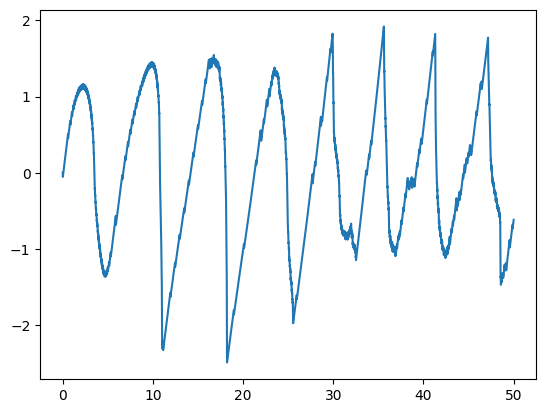

In [14]:
plt.plot(traj2.time, np.mean(traj2.angle, axis=1))

In [16]:
cou.action(-0.5)

1.0

In [18]:
plt.plot(traj2.angle, traj2.action.reshape(5000, 100))
plt.ylim(0.99, 1.01)

ValueError: cannot reshape array of size 490000 into shape (5000,100)

In [19]:
t_span = (0, 50)

In [21]:
for i in range(3):
    r0, p0 = states0[i]
    E0 = p0**2/2 + regdyn.potential.value(r0)
    T  = 2*np.pi / regdyn.potential.angular_frequency(E0)
    print(f"particle {i}: r0={r0:.4f}  E0={E0:.2f}  period={T:.2e}  "
          f"periods_in_span={(t_span[1]-t_span[0])/T:.1f}")

particle 0: r0=1.5000  E0=-0.40  period=8.78e+00  periods_in_span=5.7
particle 1: r0=1.5000  E0=-0.50  period=6.28e+00  periods_in_span=8.0
particle 2: r0=1.5000  E0=-0.60  period=4.78e+00  periods_in_span=10.5


In [23]:
states0.shape

AttributeError: 'list' object has no attribute 'shape'

In [58]:
sol, t = t, sol

In [24]:
traj = Trajectory(t, sol, cou)

NameError: name 't' is not defined

(-5.0, 5.0)

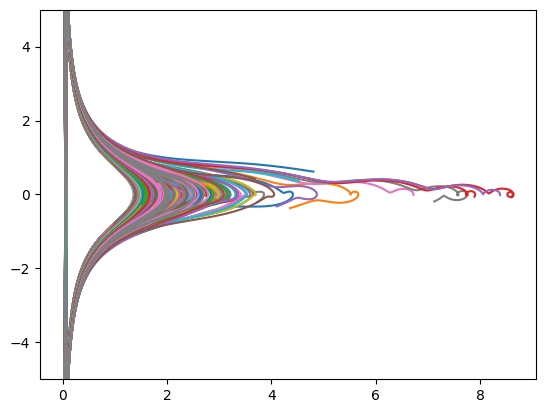

In [7]:
plt.plot(traj2.position, traj2.momentum)
plt.ylim(-5, 5)

(-5.0, 5.0)

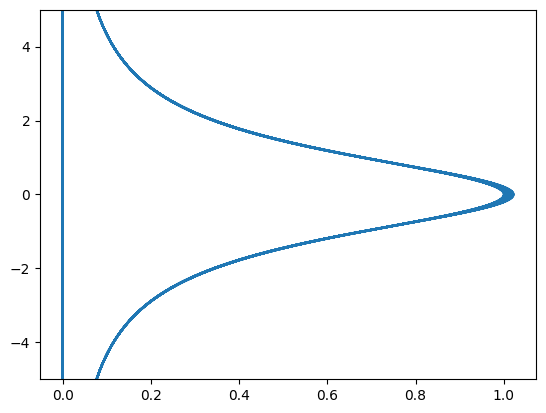

In [14]:
plt.plot(*sol2.T)
plt.ylim(-5, 5)

In [6]:
0**2/2 - 1/1

-1.0

In [40]:
t2.shape

(245755,)

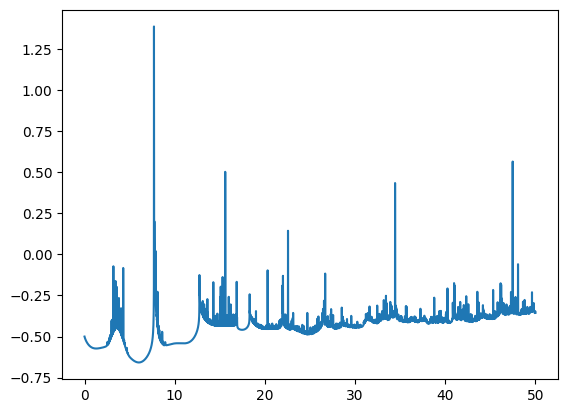

In [94]:
plt.plot(traj2.time, np.mean(traj2.energy, axis=1))

In [16]:
syst2 = ClassicalSystem.from_angle(regdyn, -0.5, 200)

In [17]:
syst2.states0

array([[ 0.1627226 , -3.36018686],
       [ 0.25570443, -2.61180598],
       [ 0.33218527, -2.24070001],
       [ 0.39927523, -2.00226773],
       [ 0.45994894, -1.82983844],
       [ 0.51581558, -1.69627674],
       [ 0.56787186, -1.58805583],
       [ 0.61679014, -1.4975293 ],
       [ 0.6630516 , -1.41998468],
       [ 0.70701589, -1.3523279 ],
       [ 0.74896097, -1.29242645],
       [ 0.78910744, -1.23875305],
       [ 0.82763416, -1.19017925],
       [ 0.86468879, -1.14584941],
       [ 0.90039506, -1.10510053],
       [ 0.93485798, -1.06740919],
       [ 0.96816768, -1.03235549],
       [ 1.00040226, -0.99959782],
       [ 1.03162997, -0.9688548 ],
       [ 1.06191092, -0.9398921 ],
       [ 1.09129838, -0.91251265],
       [ 1.11983989, -0.88654927],
       [ 1.14757804, -0.86185896],
       [ 1.17455123, -0.83831856],
       [ 1.20079423, -0.81582124],
       [ 1.22633861, -0.79427384],
       [ 1.2512132 , -0.7735946 ],
       [ 1.27544438, -0.75371143],
       [ 1.29905638,

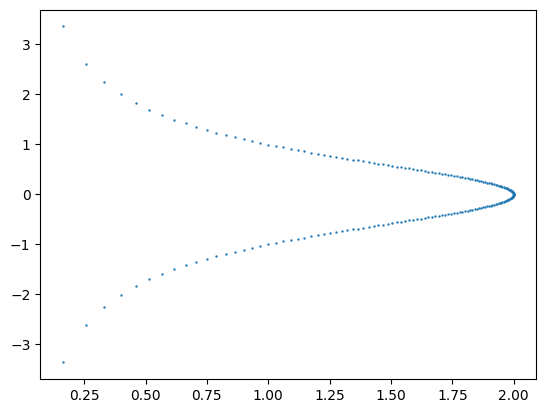

In [18]:
plt.scatter(*syst2.states0.T, s=0.5)

In [96]:
pmap = syst.poincare_map(integ, 50)

In [99]:
pmap.ionization_probability()

0.3612040133779264

In [30]:
sol2, t2 = C_forced_Phase_Space(traj.energy[0], traj.position[0], field.amplitude, field.ang_frequency, 0, 50, h=1.e-4, dt=1.e-4)

0.00039999991189334155


(-5.0, 5.0)

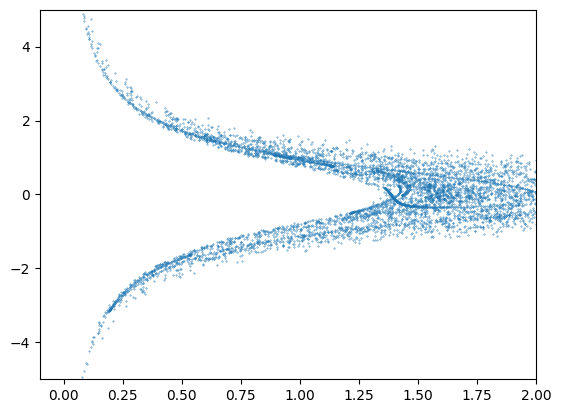

In [107]:
plt.scatter(pmap.position, pmap.momentum, s=0.1)
plt.xlim(-0.1, 2)
plt.ylim(-5, 5)

In [17]:
cou.action(np.linspace(-1, -0.00001, 10))

array([  0.70710678,   0.74999953,   0.80178258,   0.86602324,
         0.9486795 ,   1.06065354,   1.22473262,   1.49997375,
         2.1212355 , 223.60679775])

In [22]:
pos = np.linspace(0, 2, 12)
Es  = np.linspace(-0.5, -0.3, 4)

In [24]:
angs = cou.angle(Es[:, None], pos)

In [25]:
angs.shape

(4, 12)

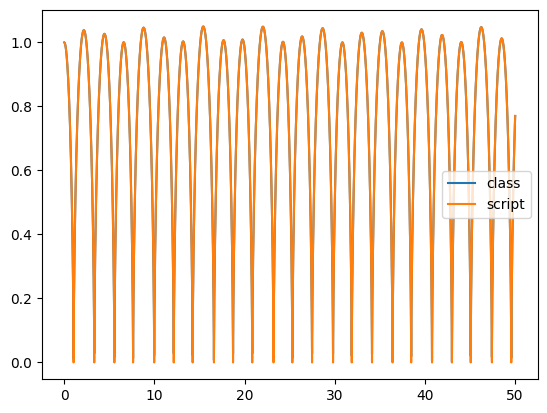

In [32]:
plt.plot(traj.time, traj.position, label="class")
plt.plot(t2, sol2[:,0], label="script")

plt.legend()
plt.show()


In [34]:
E = sol2[:,1]**2/2 - 1/sol2[:,0]

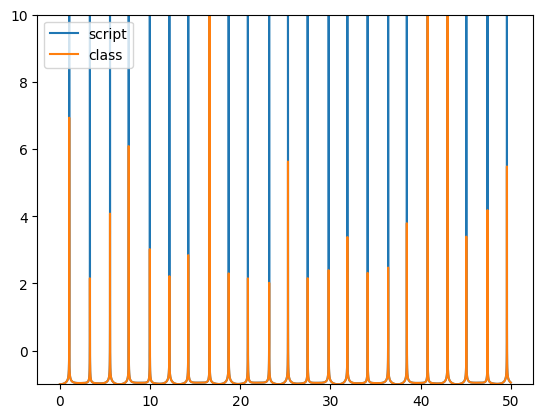

In [39]:
plt.plot(t2, E, label='script')
plt.plot(traj.time, traj.energy, label='class')

plt.legend()

plt.ylim(-1, 10)

plt.show()
